In [1]:
import polars as pl
import numpy as np
from pathlib import Path
import bisect
import pandas as pd

In [2]:
ROOT = Path("/data/xujiayi/xjy/l2")
DATE = "20260624"
EXCHANGE = "sz"

In [3]:
order = pl.read_parquet(ROOT/"proc"/DATE/f"{EXCHANGE}wt.pq").filter((pl.col('TransactTime')>pl.time(9,30)) & (pl.col('TransactTime')<pl.time(14,57)))
cancel = pl.read_parquet(ROOT/"proc"/DATE/f"{EXCHANGE}cancel.pq").filter((pl.col('TransactTime')>pl.time(9,30)) & (pl.col('TransactTime')<pl.time(14,57)))
deal = pl.read_parquet(ROOT/"proc"/DATE/f"{EXCHANGE}cj.pq").filter((pl.col('TransactTime')>pl.time(9,30)) & (pl.col('TransactTime')<pl.time(14,57)))
shot = pl.read_parquet(ROOT/"proc"/DATE/f"{EXCHANGE}shot_1m.pq").filter((pl.col('BarTime')>=pl.time(9,30)) & (pl.col('BarTime')<=pl.time(14,57)))

#### 订单激进维度

In [12]:
# 挂买
buy_order = order.filter(pl.col('Side')==1)
buy_order = buy_order.join_asof(
    shot,
    left_on="TransactTime",
    right_on="BarTime",
    by="SecurityID",
    strategy="backward",
    check_sortedness=False,
).with_columns(
    pl.when((pl.col('Price') >= pl.col('AskPrice1')) & (pl.col('OrderQty') >= pl.col('AskQty1'))).then(1)
    .when((pl.col('Price') >= pl.col('AskPrice1')) & (pl.col('OrderQty') < pl.col('AskQty1'))).then(2)
    .when((pl.col('Price') > pl.col('BidPrice1')) & (pl.col('Price') < pl.col('AskPrice1'))).then(3)
    .when(pl.col('Price') == pl.col('BidPrice1')).then(4)
    .otherwise(5)
    .alias('PassionLevel')
).select(order.columns+['PassionLevel'])

# 挂卖
sell_order = order.filter(pl.col('Side')==-1)
sell_order = sell_order.join_asof(
    shot,
    left_on="TransactTime",
    right_on="BarTime",
    by="SecurityID",
    strategy="backward",
    check_sortedness=False,
).with_columns(
    pl.when((pl.col('Price') <= pl.col('BidPrice1')) & (pl.col('OrderQty') >= pl.col('BidQty1'))).then(1)
    .when((pl.col('Price') <= pl.col('BidPrice1')) & (pl.col('OrderQty') < pl.col('BidQty1'))).then(2)
    .when((pl.col('Price') < pl.col('AskPrice1')) & (pl.col('Price') > pl.col('BidPrice1'))).then(3)
    .when(pl.col('Price') == pl.col('AskPrice1')).then(4)
    .otherwise(5)
    .alias('PassionLevel')
).select(order.columns+['PassionLevel'])


In [13]:
len(buy_order), len(sell_order)

(93065545, 92664020)

#### 成交维度

In [51]:
deal = deal.with_columns(
    pl.when((0<=pl.col('OrderQty')) & (pl.col('OrderQty')<50000)).then(1)
    .when((50000<=pl.col('OrderQty')) & (pl.col('OrderQty')<300000)).then(2)
    .when((300000<=pl.col('OrderQty')) & (pl.col('OrderQty')<1000000)).then(3)
    .otherwise(4)
    .alias('Size')
)
# 主买
active_buy = deal.filter(pl.col('BidApplSeqNum')>pl.col('OfferApplSeqNum'))
# 主卖
active_sell = deal.filter(pl.col('BidApplSeqNum')<pl.col('OfferApplSeqNum'))


#### 时间维度

In [72]:
qty_bin = order.sort(["SecurityID",'TransactTime','ApplSeqNum']).join_asof(
    shot.select(["BarTime","SecurityID"]),
    left_on="TransactTime",
    right_on="BarTime",
    by="SecurityID",
    strategy="backward",
    check_sortedness=False,
)
qty_bin

ChannelNo,ApplSeqNum,SecurityID,Price,OrderQty,Side,TransactTime,OrdType,LocalTime,SeqNo,BarTime
i64,i64,i64,f64,i64,i8,time,i64,str,i64,time
2011,568840,1,10.67,300,1,09:30:00.010,50,"""09:30:00.120""",2706834,09:30:00
2011,569183,1,10.78,1000,-1,09:30:00.010,50,"""09:30:00.131""",2707570,09:30:00
2011,569710,1,10.69,7000,-1,09:30:00.020,50,"""09:30:00.153""",2709269,09:30:00
2011,569759,1,10.89,500,-1,09:30:00.020,50,"""09:30:00.160""",2709527,09:30:00
2011,570393,1,10.66,10000,1,09:30:00.030,50,"""09:30:00.184""",2711299,09:30:00
…,…,…,…,…,…,…,…,…,…,…
2012,61486317,302132,57.95,200,1,14:56:56.160,50,"""14:56:56.169""",188401271,14:56:00
2012,61491229,302132,57.96,500,1,14:56:57.410,50,"""14:56:57.416""",188412895,14:56:00
2012,61498626,302132,57.9,100,1,14:56:59.200,50,"""14:56:59.207""",188428746,14:56:00


In [73]:
limit = 1.2
n = 5

# 1. 按股票、时间、序号排序，确保移位顺序正确
minute_qty_bin = qty_bin.group_by(['SecurityID', 'BarTime']).agg(
    pl.col('OrderQty').sum().alias('MinuteQty')
).sort(['SecurityID', 'BarTime'])

# 2. 计算前后分钟均值（固定分母 n）
surrounding_sum = 0
for i in range(1, n//2 + 1):
    surrounding_sum += (
        pl.col('MinuteQty').shift(i).over('SecurityID').fill_null(0) +
        pl.col('MinuteQty').shift(-i).over('SecurityID').fill_null(0)
    )
surround_mean = surrounding_sum / n

minute_df = minute_qty_bin.with_columns([
    surround_mean.alias('surround_mean'),
    (pl.col('MinuteQty') / surround_mean).alias('ratio'),
    ((pl.col('MinuteQty') / surround_mean) > limit).cast(pl.Int32).alias('Custer')
])

# 3. 回填到原始逐笔数据
res = qty_bin.join(
    minute_df, on=['SecurityID', 'BarTime'], how='left'
)
res

ChannelNo,ApplSeqNum,SecurityID,Price,OrderQty,Side,TransactTime,OrdType,LocalTime,SeqNo,BarTime,MinuteQty,surround_mean,ratio,Custer
i64,i64,i64,f64,i64,i8,time,i64,str,i64,time,i64,f64,f64,i32
2011,568840,1,10.67,300,1,09:30:00.010,50,"""09:30:00.120""",2706834,09:30:00,10148300,2451842.4,4.139051,1
2011,569183,1,10.78,1000,-1,09:30:00.010,50,"""09:30:00.131""",2707570,09:30:00,10148300,2451842.4,4.139051,1
2011,569710,1,10.69,7000,-1,09:30:00.020,50,"""09:30:00.153""",2709269,09:30:00,10148300,2451842.4,4.139051,1
2011,569759,1,10.89,500,-1,09:30:00.020,50,"""09:30:00.160""",2709527,09:30:00,10148300,2451842.4,4.139051,1
2011,570393,1,10.66,10000,1,09:30:00.030,50,"""09:30:00.184""",2711299,09:30:00,10148300,2451842.4,4.139051,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2012,61486317,302132,57.95,200,1,14:56:56.160,50,"""14:56:56.169""",188401271,14:56:00,67100,39880.0,1.682548,1
2012,61491229,302132,57.96,500,1,14:56:57.410,50,"""14:56:57.416""",188412895,14:56:00,67100,39880.0,1.682548,1
2012,61498626,302132,57.9,100,1,14:56:59.200,50,"""14:56:59.207""",188428746,14:56:00,67100,39880.0,1.682548,1


BarTime,MinuteQty,Custer
time,i64,i32
09:30:00,10148300,1
09:31:00,9165412,1
09:33:00,4799200,1
09:37:00,4912376,1
09:39:00,5223500,1
…,…,…
14:49:00,1156500,1
14:52:00,2132500,1
14:54:00,1870600,1


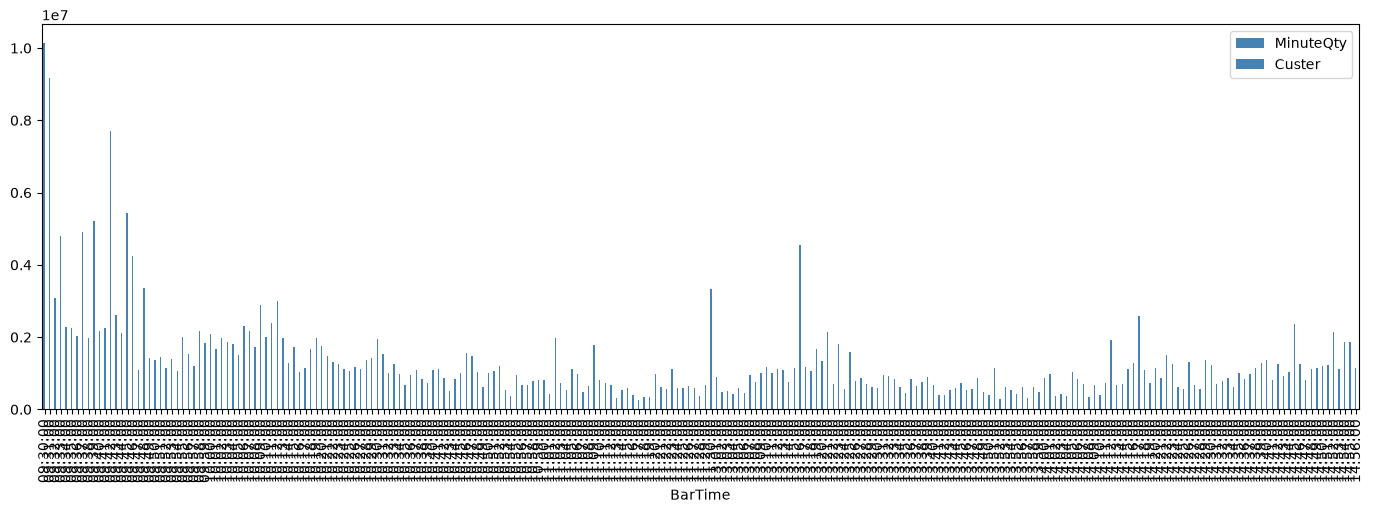

In [76]:
import matplotlib.pyplot as plt
tmp = res.filter(pl.col('SecurityID')==1).select(['BarTime','MinuteQty','Custer']).unique().sort('BarTime')
colors = ['steelblue' if val == 1 else 'red' for val in tmp['Custer']]
tmp.to_pandas().set_index('BarTime').plot(kind='bar', figsize=(17,5), color=colors)
tmp.filter(pl.col('Custer')==1) 

In [ ]:
buy_passionlevel_count = buy_order.group_by(['SecurityID','PassionLevel']).agg(pl.col('PassionLevel').count().alias('LevelCount')).sort(['SecurityID','PassionLevel'])
buy_passionlevel_count = buy_passionlevel_count.with_columns(
    (pl.col('LevelCount')/pl.col('LevelCount').sum().over('SecurityID')).alias('LevelProportion')
)

sell_passionlevel_count = sell_order.group_by(['SecurityID','PassionLevel']).agg(pl.col('PassionLevel').count().alias('LevelCount')).sort(['SecurityID','PassionLevel'])
sell_passionlevel_count = sell_passionlevel_count.with_columns(
    (pl.col('LevelCount')/pl.col('LevelCount').sum().over('SecurityID')).alias('LevelProportion')
)

all_securities = buy_passionlevel_count.select('SecurityID').unique().vstack(
    sell_passionlevel_count.select('SecurityID').unique()
).unique()
all_levels = pl.DataFrame({'PassionLevel': [1, 2, 3, 4, 5]})
all_combinations = all_securities.join(all_levels, how='cross')

passionlevel_count = (
    all_combinations
    .join(
        buy_passionlevel_count,
        on=['SecurityID', 'PassionLevel'],
        how='left'
    ).with_columns([
        pl.col('LevelCount').fill_null(0).alias('LevelCount_buy'),
        pl.col('LevelProportion').fill_null(0).alias('LevelProportion_buy')
    ]).drop(['LevelCount', 'LevelProportion'])
    .join(
        sell_passionlevel_count,
        on=['SecurityID', 'PassionLevel'],
        how='left'
    ).with_columns([
        pl.col('LevelCount').fill_null(0).alias('LevelCount_sell'),
        pl.col('LevelProportion').fill_null(0).alias('LevelProportion_sell')
    ]).drop(['LevelCount', 'LevelProportion'])
).sort(['SecurityID','PassionLevel'])
passionlevel_count

SecurityID,PassionLevel,LevelCount_buy,LevelProportion_buy,LevelCount_sell,LevelProportion_sell
i64,i64,u32,f64,u32,f64
1,1,236,0.003878,1149,0.022379
1,2,18512,0.304224,23093,0.449788
1,3,649,0.010666,858,0.016711
1,4,23563,0.387231,17302,0.336995
1,5,17890,0.294002,8940,0.174126
…,…,…,…,…,…
302132,1,1869,0.104565,2861,0.144131
302132,2,6445,0.36058,6306,0.317683
302132,3,1718,0.096117,2446,0.123224


In [87]:
###订单激进度净偏向
factor_tilt = passionlevel_count.with_columns(
    pl.when(pl.col('PassionLevel')==1).then(5)
    .when(pl.col('PassionLevel')==2).then(4)
    .when(pl.col('PassionLevel')==3).then(3)
    .when(pl.col('PassionLevel')==4).then(2)
    .when(pl.col('PassionLevel')==5).then(1)
    .otherwise(0)
    .alias('LevelScore')
).with_columns(
    pl.col('LevelScore')*(pl.col('LevelProportion_buy')-pl.col('LevelProportion_sell')).alias('factor_tilt')
).group_by('SecurityID').agg(pl.col('LevelScore').sum())


In [88]:
ticks = np.load("/data/xujiayi/xjy/axis/ticks.npy", allow_pickle=True)
dates = np.load("/data/xujiayi/xjy/axis/dates.npy", allow_pickle=True)

factor_tilt = factor_tilt.to_pandas().set_index('SecurityID')
factor_tilt.index = factor_tilt.index.astype(str).str.zfill(6)
factor_tilt = factor_tilt.reindex(ticks)

In [84]:
import pymssql

JY_CONFIG = {
    "server": '10.10.0.102',
    "user": 'jydbReader',
    "password": 'jy@9043!Reader',
    "database": 'jydb',
    "charset": 'cp936'
}
JY_CONN = pymssql.connect(**JY_CONFIG)

sql_field = f'''select
                    C.SecuCode as "tick",
                    A.ChangePCT as "pct"
                from QT_StockPerformance A
                left join SecuMain C
                on A.InnerCode = C.InnerCode
                where A.TradingDay='{"2026-06-26"}'
                    and C.SecuMarket in (83,90)
                    and C.SecuCategory=1
                union all
                select
                    C.SecuCode as "tick",
                    B.ChangePCT as "pct"
                from LC_STIBPerformance B
                left join SecuMain C
                on B.InnerCode = C.InnerCode
                where B.TradingDay='{"2026-06-26"}'
                    and C.SecuMarket in (83,90)
                    and C.SecuCategory=1
                '''
d_pct = pl.read_database(sql_field, JY_CONN).sort('tick')
d_pct = d_pct.to_pandas().set_index('tick').reindex(ticks)
d_pct

,pct
tick,
000001,-1.8234
000002,2.0339
000004,7.6923
000005,NaN
000006,-2.5815
...,...
688805,-5.5644
688807,-10.2325
688809,-5.2597


In [110]:
import bottleneck as bn

label = d_pct.values.astype(float).reshape(1,-1)
pred1 = factor_tilt.values.astype(float).reshape(1,-1)

def corr(a, b, axis):
    b[np.isnan(a)] = np.nan
    a[np.isnan(b)] = np.nan
    arr = (
            (bn.nanmean(a * b, axis=axis) - bn.nanmean(a, axis=axis) * bn.nanmean(b, axis=axis))
            / (bn.nanstd(a, axis=axis) + 1e-6)
            / (bn.nanstd(b, axis=axis) + 1e-6)
    )
    bn.replace(arr, np.nan, 0)
    arr[np.isinf(arr)] = 0
    return arr

def IC(y_, y):
    ics = corr(y_.copy(), y.copy(), axis=1)
    return ics

def rankIC(y_, y):
    rank_ics = corr(bn.nanrankdata(y_.copy(), axis=1), bn.nanrankdata(y.copy(), axis=1), axis=1)
    return rank_ics

In [113]:
rankIC(pred1, label)

array([-0.08575076])

In [106]:
factor_extreme = (
    passionlevel_count
    .group_by('SecurityID')
    .agg(
        (pl.col('LevelCount_buy').filter(pl.col('PassionLevel')==1).first() + 
         pl.col('LevelCount_sell').filter(pl.col('PassionLevel')==1).first()) / 
        (pl.col('LevelCount_buy').filter(pl.col('PassionLevel')==5).first() + 
         pl.col('LevelCount_sell').filter(pl.col('PassionLevel')==5).first())
        .alias('factor_extreme')
    )
)

In [108]:
factor_extreme = factor_extreme.to_pandas().set_index('SecurityID')
factor_extreme.index = factor_extreme.index.astype(str).str.zfill(6)
factor_extreme = factor_extreme.reindex(ticks)
factor_extreme

,LevelCount_buy
SecurityID,
000001,0.051621
000002,0.006516
000004,0.041916
000005,NaN
000006,0.136749
...,...
688805,NaN
688807,NaN
688809,NaN


In [112]:
label = d_pct.values.astype(float).reshape(1,-1)
pred2 = factor_extreme.values.astype(float).reshape(1,-1)

rankIC(pred2, label)

array([-0.05752338])

In [114]:
rankIC(pred1*pred2, label)

array([-0.031836])